 ## Note
 **One Class SVM:** 平面 $w \cdot x = \rho$について、原点を通る平面から
 $$ \frac{|\rho|}{\|w\|}$$
 だけ移動した平面となっている<br/>
 ここで、データに対して
 $$ w \cdot x \ge \rho$$
 の制約を満たすように、$w$と$\rho$を最適化しデータが存在する領域の境界を学習することを考える<br/>
 これは、原点を通る平面からのマージン $|\rho|/\|w\|$ を最大化する問題になる

 ただし、全てのデータが制約を満たせるとは限らないため、スラック変数$\xi_i \ge 0$を用いて
 $$ w \cdot x_i \ge \rho - \xi_i $$
 と制約を緩和する<br/>
 $\xi$について、SVM同様にmaxで書き下すと以下になる
 $$ \xi_i = max(0, \rho - w \cdot x_i) $$

 **One Class SVMの定式化:** $w$と$\xi$を最小化し、$\rho$を最大化する問題となるので、
 $$ \begin{align*}
 &min_{w,\rho,\xi} \frac12\|w\|^2 -\rho +\frac{1}{\nu n} \sum_{i=1}^{n}\xi_i \\
 \text{subject to} \\
 &w \cdot x_i \ge \rho - \xi_i \\
 &\xi_i \ge 0
 \end {align*}$$
 となる <br/>
 ここで、$\nu \in (0, 1]$ であり、制約を満たさないデータの割合に対応する<br/>
 スラック変数をmaxで置き換えると
 $$
 min_{w,\rho,\xi} \frac12\|w\|^2 -\rho +\frac{1}{\nu n} \sum_{i=1}^{n} max(0, \rho - w \cdot x_i) \\
 $$
 となる

 **SGDでの更新式:**
 $$ \begin{align*}
 w_{t+1} &\leftarrow (1 - \eta) w_t + \frac{\eta}{\nu} x_i \mathbf{1}[w_t \cdot x_i < \rho_t] \\
 \rho_{t+1} &\leftarrow \rho_t + \eta - \frac{\eta}{\nu} \mathbf{1}[w_t \cdot x_i < \rho_t]
 \end{align*}$$
 場合分けしていくと
 - $w \cdot x \ge \rho$の場合
   - $w_{t+1} \leftarrow (1 - \eta) w_t$
   - $\rho_{t+1} \leftarrow \rho_t + \eta$
 - $w \cdot x < \rho$の場合
   - $w_{t+1} \leftarrow (1 - \eta) w_t + \frac{\eta}{\nu} x_i$
   - $\rho_{t+1} \leftarrow \rho_t + \eta - \frac{\eta}{\nu}$

In [ ]:
import numpy as np
from IPython.display import display
from numpy.typing import ArrayLike, NDArray
from step4_perceptron import TrainLogAnimation
from step5_linear_svm import LinearSupportVectorMachine

rng = np.random.default_rng(123)


def init_single_class_dataset(
    mean: ArrayLike | NDArray,
    std: ArrayLike | NDArray | float = 1.0,
    n_samples: int = 300,
) -> tuple[NDArray, NDArray]:
    mean = np.asarray(mean)
    std = np.asarray(std)

    X = rng.normal(
        loc=mean,
        scale=std,
        size=(n_samples, mean.shape[0]),
    )

    y = np.ones(n_samples, dtype=int)

    return X, y

In [ ]:
class LinearOneClassSupportVectorMachine(LinearSupportVectorMachine):
    def __init__(
        self,
        ndim: int = 2,
        eta: float = 0.0003,
        nu: float = 0.05,
        tolerance: float = 0.1,
        patience: int = 10,
    ):
        super().__init__(ndim=ndim, eta=eta)
        self.nu = nu
        self.tolerance = tolerance
        self.patience = patience
        self._convergence_count = 0

    def _train_step(self, x: NDArray, y: float) -> tuple[NDArray, float]:
        if self.score(x) < 0:
            w = (1 - self.eta) * self.w + self.eta / self.nu * x
            b = self.b + self.eta - self.eta / self.nu
        else:
            w = (1 - self.eta) * self.w
            b = self.b + self.eta
        return (w, b)

    def score(self, X: NDArray) -> NDArray:
        # w・x - pと対応させるため符号が逆になる
        return X @ self.w - self.b

epoch 1: delta = np.float64(1.5267750699543856)
epoch 2: delta = np.float64(0.1346667960870498)
epoch 3: delta = np.float64(0.11661266137886375)
epoch 4: delta = np.float64(0.11328883888261751)
epoch 5: delta = np.float64(0.09899553820100015)
epoch 6: delta = np.float64(0.08866047105687397)
epoch 7: delta = np.float64(0.08722631846237792)
epoch 8: delta = np.float64(0.08591561937992626)
epoch 9: delta = np.float64(0.10340590689092238)
epoch 10: delta = np.float64(0.08161032257730891)
epoch 11: delta = np.float64(0.08078305490815703)
epoch 12: delta = np.float64(0.09476830674189579)
epoch 13: delta = np.float64(0.07755071341978359)
epoch 14: delta = np.float64(0.09181412082563589)
epoch 15: delta = np.float64(0.0895920114848947)
epoch 16: delta = np.float64(0.0728219244412523)
epoch 17: delta = np.float64(0.08749063360450354)
epoch 18: delta = np.float64(0.08564069503818339)
epoch 19: delta = np.float64(0.08395000132067276)
n_frames = 5701, n_samples = 150


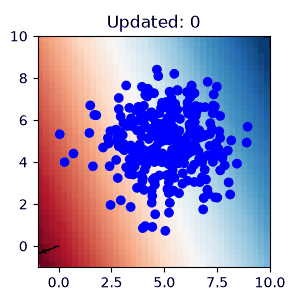

In [ ]:
def main():
    Dx, Dy = init_single_class_dataset(mean=[5, 5], std=1.5)

    model = LinearOneClassSupportVectorMachine()
    history = model.train(Dx, Dy)
    output_frames = 150
    frame_sampling_rate = min(1.0, output_frames / len(history))

    log_anim = TrainLogAnimation(
        history,
        xlim=(-1, 10),
        ylim=(-1, 10),
    )
    display(log_anim.plot(figsize=(3, 3), frame_sampling_rate=frame_sampling_rate))


if __name__ == "__main__":
    main()